In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# PRE-STEP: Interpolate missing SC-ST values for Karnataka, West Bengal, Ladakh
# ═══════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import re, os

# FIX: Use working directory (not __file__)
DATA_DIR = os.getcwd()

def norm(s):
    if pd.isna(s): return np.nan
    return re.sub(r'\s+', ' ', str(s).strip().upper())

sc_st = pd.read_csv(os.path.join(DATA_DIR, 'mgnrega_sc-st.csv'))
sc_st.columns = sc_st.columns.str.strip()
sc_st['District'] = sc_st['District'].apply(norm)
sc_st['State']    = sc_st['State'].apply(norm)

sc_st['Year'] = sc_st['Year'].apply(
    lambda x: int(re.match(r'(\d{4})', str(x)).group(1))
    if pd.notnull(x) and re.match(r'(\d{4})', str(x)) else np.nan
).astype('Int64')

TARGET_YEARS = list(range(2014, 2025))
VALUE_COLS   = ['Women_Employment_Provided', 'Workers_SC', 'Workers_ST', 'Workers_Total']

# ── West Bengal: district consolidation ─────────────────────────────────────
WB_ALIAS = {
    '24 PARGANAS (NORTH)' : 'NORTH TWENTY FOUR PARGANAS',
    '24 PARGANAS SOUTH'   : 'SOUTH TWENTY FOUR PARGANAS',
    'NORTH 24 PARGANAS'   : 'NORTH TWENTY FOUR PARGANAS',
    'SOUTH 24 PARGANAS'   : 'SOUTH TWENTY FOUR PARGANAS',
    'DINAJPUR DAKSHIN'    : 'DAKSHIN DINAJPUR',
    'DINAJPUR UTTAR'      : 'UTTAR DINAJPUR',
    'DARJEELING GORKHA HILL COUNCIL (DGHC)'  : 'DARJEELING',
    'GORKHALAND TERRITORIAL ADMINISTRATION (GTA)': 'DARJEELING',
    'PURBA BARDHAMAN'     : 'BARDHAMAN',
    'PASCHIM BARDHAMAN'   : 'BARDHAMAN',
}

wb_mask = sc_st['State'] == 'WEST BENGAL'
sc_st.loc[wb_mask, 'District'] = sc_st.loc[wb_mask, 'District'].map(
    lambda x: WB_ALIAS.get(x, x)
)

# Aggregate duplicates after aliasing
sc_st = sc_st.groupby(['District', 'State', 'Year'], as_index=False)[VALUE_COLS].sum(min_count=1)

# ── Helper: interpolate a state's missing district-years ─────────────────────
def interpolate_state(df, state):
    sub    = df[df['State'] == state].copy()
    others = df[df['State'] != state].copy()

    # SAFETY CHECK (important for Ladakh)
    if sub['Year'].nunique() < 3:
        print(f"WARNING: Too few data points for reliable interpolation: {state}")

    districts = sub['District'].unique()

    full_idx = pd.MultiIndex.from_product(
        [districts, TARGET_YEARS], names=['District', 'Year']
    )
    full = pd.DataFrame(index=full_idx).reset_index()
    full['State'] = state

    merged = full.merge(sub, on=['District', 'State', 'Year'], how='left')

    for col in VALUE_COLS:
        merged[col] = merged.groupby('District')[col].transform(
            lambda s: s.interpolate(method='linear', limit_direction='both')
        )
        merged[col] = merged[col].clip(lower=0).round(0)

    return pd.concat([others, merged], ignore_index=True)

# Apply interpolation
for state in ['KARNATAKA', 'WEST BENGAL', 'LADAKH']:
    before = sc_st[sc_st['State'] == state].shape[0]
    sc_st = interpolate_state(sc_st, state)
    after  = sc_st[sc_st['State'] == state].shape[0]
    print(f'{state}: rows {before} -> {after}')

# ── Verification ────────────────────────────────────────────────────────────
print('\nPost-interpolation check:')
for state in ['KARNATAKA', 'WEST BENGAL', 'LADAKH']:
    sub = sc_st[sc_st['State'] == state]
    for dist in sub['District'].unique():
        years_present = sorted(sub[sub['District'] == dist]['Year'].tolist())
        missing = [y for y in TARGET_YEARS if y not in years_present]
        if missing:
            print(f'MISSING: {state} / {dist}: {missing}')

# ── Save (OVERWRITE as requested) ───────────────────────────────────────────
out_path = os.path.join(DATA_DIR, 'mgnrega_sc-st.csv')
sc_st.to_csv(out_path, index=False)

print(f'\nSaved (overwritten): {out_path}')
print(f'Total rows: {len(sc_st)}')


c:\Users\Tanishq op\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Tanishq op\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


KARNATAKA: rows 352 -> 352
WEST BENGAL: rows 242 -> 242
LADAKH: rows 22 -> 22

Post-interpolation check:

Saved (overwritten): c:\Users\Tanishq op\Downloads\MGNERA Project Dataset\Final Datasets\mgnrega_sc-st.csv
Total rows: 8458


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# PRE-STEP: Interpolate missing SC-ST values for Karnataka, West Bengal, Ladakh
# ═══════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import re, os

DATA_DIR = os.path.dirname(os.path.abspath('__file__'))

def norm(s):
    if pd.isna(s): return np.nan
    return re.sub(r'\s+', ' ', str(s).strip().upper())

sc_st = pd.read_csv(os.path.join(DATA_DIR, 'mgnrega_sc-st.csv'))
sc_st.columns = sc_st.columns.str.strip()
sc_st['District'] = sc_st['District'].apply(norm)
sc_st['State']    = sc_st['State'].apply(norm)
sc_st['Year'] = sc_st['Year'].apply(
    lambda x: int(re.match(r'(\d{4})', str(x)).group(1))
    if pd.notnull(x) and re.match(r'(\d{4})', str(x)) else np.nan
).astype('Int64')

TARGET_YEARS = list(range(2014, 2025))
VALUE_COLS   = ['Women_Employment_Provided', 'Workers_SC', 'Workers_ST', 'Workers_Total']

# ── West Bengal: consolidate duplicate/renamed district entries ──────────────
# The dataset has old names AND new names for the same districts.
# Consolidate so each district has one entry per year: keep non-null, sum where needed.
WB_ALIAS = {
    '24 PARGANAS (NORTH)'                    : 'NORTH TWENTY FOUR PARGANAS',
    '24 PARGANAS SOUTH'                      : 'SOUTH TWENTY FOUR PARGANAS',
    'NORTH 24 PARGANAS'                      : 'NORTH TWENTY FOUR PARGANAS',
    'SOUTH 24 PARGANAS'                      : 'SOUTH TWENTY FOUR PARGANAS',
    'DINAJPUR DAKSHIN'                       : 'DAKSHIN DINAJPUR',
    'DINAJPUR UTTAR'                         : 'UTTAR DINAJPUR',
    'DARJEELING GORKHA HILL COUNCIL (DGHC)'  : 'DARJEELING',
    'GORKHALAND TERRITORIAL ADMINISTRATION (GTA)': 'DARJEELING',
    'PURBA BARDHAMAN'                        : 'BARDHAMAN',
    'PASCHIM BARDHAMAN'                      : 'BARDHAMAN',
}

wb_mask = sc_st['State'] == 'WEST BENGAL'
sc_st.loc[wb_mask, 'District'] = sc_st.loc[wb_mask, 'District'].map(
    lambda x: WB_ALIAS.get(x, x)
)

# After alias, aggregate rows with same (District, State, Year) by summing
# (because two old rows that map to one new district should be summed)
non_val = [c for c in sc_st.columns if c not in VALUE_COLS]
sc_st = sc_st.groupby(['District', 'State', 'Year'], as_index=False)[VALUE_COLS].sum(min_count=1)

print('After WB consolidation, West Bengal districts:',
      sorted(sc_st[sc_st['State']=='WEST BENGAL']['District'].unique()))

# ── Helper: interpolate a state's missing district-years ─────────────────────
def interpolate_state(df, state):
    sub    = df[df['State'] == state].copy()
    others = df[df['State'] != state].copy()

    districts = sub['District'].unique()
    # Build a full grid
    full_idx = pd.MultiIndex.from_product(
        [districts, TARGET_YEARS], names=['District', 'Year']
    )
    full = pd.DataFrame(index=full_idx).reset_index()
    full['State'] = state

    merged = full.merge(sub, on=['District', 'State', 'Year'], how='left')

    # Interpolate each value column per district (linear, then fill edges)
    for col in VALUE_COLS:
        merged[col] = merged.groupby('District')[col].transform(
            lambda s: s.interpolate(method='linear', limit_direction='both')
        )
        # Clip to 0 (no negative counts)
        merged[col] = merged[col].clip(lower=0).round(0)

    return pd.concat([others, merged], ignore_index=True)

# Apply interpolation for each target state
for state in ['KARNATAKA', 'WEST BENGAL', 'LADAKH']:
    before = sc_st[sc_st['State'] == state].shape[0]
    sc_st = interpolate_state(sc_st, state)
    after  = sc_st[sc_st['State'] == state].shape[0]
    print(f'{state}: rows {before} -> {after} (added {after - before} interpolated rows)')

# ── Verify no missing years for target states ─────────────────────────────────
print('\nPost-interpolation check:')
for state in ['KARNATAKA', 'WEST BENGAL', 'LADAKH']:
    sub = sc_st[sc_st['State'] == state]
    for dist in sorted(sub['District'].unique()):
        years_present = sorted(sub[sub['District'] == dist]['Year'].tolist())
        missing = [y for y in TARGET_YEARS if y not in years_present]
        if missing:
            print(f'  STILL MISSING: {state} / {dist}: {missing}')
print('  Done - no remaining gaps shown above (silence = all clear)')

# ── Save patched SC-ST file ───────────────────────────────────────────────────
out_path = os.path.join(DATA_DIR, 'mgnrega_sc-st.csv')
sc_st.to_csv(out_path, index=False)
print(f'\nSaved interpolated SC-ST file: {out_path}')
print(f'Total rows: {len(sc_st)}')


After WB consolidation, West Bengal districts: ['ALIPURDUAR', 'BANKURA', 'BARDHAMAN', 'BIRBHUM', 'COOCHBEHAR', 'DAKSHIN DINAJPUR', 'DARJEELING', 'HOOGHLY', 'HOWRAH', 'JALPAIGURI', 'JHARGRAM', 'KALIMPONG', 'MALDAH', 'MURSHIDABAD', 'NADIA', 'NORTH TWENTY FOUR PARGANAS', 'PASCHIM MEDINIPUR', 'PURBA MEDINIPUR', 'PURULIA', 'SILIGURI MAHAKUMA PARISAD', 'SOUTH TWENTY FOUR PARGANAS', 'UTTAR DINAJPUR']
KARNATAKA: rows 352 -> 352 (added 0 interpolated rows)
WEST BENGAL: rows 242 -> 242 (added 0 interpolated rows)
LADAKH: rows 22 -> 22 (added 0 interpolated rows)

Post-interpolation check:
  Done - no remaining gaps shown above (silence = all clear)

Saved interpolated SC-ST file: c:\Users\Tanishq op\Downloads\MGNERA Project Dataset\Final Datasets\mgnrega_sc-st.csv
Total rows: 8458


# MGNREGA Panel Data Construction

**Goal**: Build a balanced district-year panel where every district is present in **all** datasets for **all** common years.  
**Strategy**: 
1. Audit each dataset (districts, years, coverage)
2. Normalize district names via alias map + fuzzy matching
3. Find the intersection of districts × years
4. Merge all panel datasets on (District, Year)
5. Attach static datasets (MPI, population)
6. QC checks + export

In [4]:
import pandas as pd
import numpy as np
import os
import re
import difflib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = os.path.dirname(os.path.abspath('__file__'))
print(f'Working directory: {DATA_DIR}')

Working directory: c:\Users\Tanishq op\Downloads\MGNERA Project Dataset\Final Datasets


## Cell 2 — Load & Audit Each Dataset

In [5]:
# ── File registry ────────────────────────────────────────────────────────────
# Panel datasets (have both District + Year) → will be inner-merged
PANEL_FILES = {
    'employment'  : 'mgnrega_employment.csv',
    'wage'        : 'mgnrega_wage.csv',
    'sc_st'       : 'mgnrega_sc-st.csv',
    'agriculture' : 'district_agriculture_panel.csv',
    'asset'       : 'district_asset_index.csv',
    'rainfall'    : 'district_rainfall_2014_2025.csv',
    'income'      : 'district_year_income.csv',
    'consumption' : 'annual_consumption_by_district.csv',
}

# Static datasets (District only, no Year) → merged once after panel is built
STATIC_FILES = {
    'mpi'        : 'District-Level MPI.csv',
    'population' : 'rural_population_area.csv',
}

# ── Helper: normalise a single district name ─────────────────────────────────
def norm(s):
    """Strip, uppercase, collapse spaces."""
    if pd.isna(s):
        return np.nan
    return re.sub(r'\s+', ' ', str(s).strip().upper())

# ── Load all files ───────────────────────────────────────────────────────────
def load_csv(fname):
    df = pd.read_csv(os.path.join(DATA_DIR, fname))
    # Normalise column names
    df.columns = df.columns.str.strip()
    # Normalise District
    if 'District' in df.columns:
        df['District'] = df['District'].apply(norm)
    # Normalise Year: extract leading 4-digit year
    if 'Year' in df.columns:
        df['Year'] = df['Year'].apply(
            lambda x: int(re.match(r'(\d{4})', str(x)).group(1))
            if pd.notnull(x) and re.match(r'(\d{4})', str(x)) else np.nan
        )
        df['Year'] = df['Year'].astype('Int64')
    return df

panel_dfs  = {k: load_csv(v) for k, v in PANEL_FILES.items()}
static_dfs = {k: load_csv(v) for k, v in STATIC_FILES.items()}

# ── Audit table ──────────────────────────────────────────────────────────────
audit_rows = []
for key, df in panel_dfs.items():
    years = sorted(df['Year'].dropna().unique().tolist())
    audit_rows.append({
        'Dataset'         : key,
        'Rows'            : len(df),
        'Unique Districts': df['District'].nunique(),
        'Year Min'        : min(years) if years else None,
        'Year Max'        : max(years) if years else None,
        'Years Available' : str(years),
        'Missing Dist %'  : f"{df['District'].isna().mean()*100:.1f}%",
    })

audit_df = pd.DataFrame(audit_rows)
print('=== DATASET AUDIT ===')
print(audit_df.to_string(index=False))

=== DATASET AUDIT ===
    Dataset  Rows  Unique Districts  Year Min  Year Max                                                                Years Available Missing Dist %
 employment  8499               760      2014      2025       [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]           0.0%
       wage  8851               764      2014      2025       [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]           0.0%
      sc_st  8458               754      2014      2025       [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]           0.0%
agriculture  8335               637      2013      2025 [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]           0.0%
      asset  5785               526      2014      2025       [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]           0.0%
   rainfall 15816               659      2014      2025       [2014, 2015, 201

## Cell 3 — District Name Normalisation (Alias Map + Fuzzy Matching)

In [6]:
# ── Manual alias map ─────────────────────────────────────────────────────────
# Maps non-standard / old names → standard name used in the majority of datasets
# Add more entries here if fuzzy check (below) reveals additional mismatches.
ALIAS_MAP = {
    # Andhra Pradesh
    'CUDDAPAH'              : 'KADAPA',
    'Y.S.R'                 : 'KADAPA',
    'YSR'                   : 'KADAPA',
    'EAST GODAVARI'         : 'EAST GODAVARI',
    'WEST GODAVARI'         : 'WEST GODAVARI',

    # Telangana (split from AP in 2014)
    'WARANGAL URBAN'        : 'WARANGAL',
    'WARANGAL RURAL'        : 'WARANGAL',
    'HANAMKONDA'            : 'WARANGAL',
    'KHAMMAM'               : 'KHAMMAM',
    'MAHBUBNAGAR'           : 'MAHABUBNAGAR',
    'NALGONDA'              : 'NALGONDA',
    'RANGAREDDY'            : 'RANGA REDDY',
    'RANGA REDDY'           : 'RANGA REDDY',

    # Bihar
    'PURBI CHAMPARAN'       : 'EAST CHAMPARAN',
    'PASCHIM CHAMPARAN'     : 'WEST CHAMPARAN',
    'PASHCHIM CHAMPARAN'    : 'WEST CHAMPARAN',

    # Chhattisgarh
    'JANJGIR CHAMPA'        : 'JANJGIR-CHAMPA',
    'JANJGIR - CHAMPA'      : 'JANJGIR-CHAMPA',

    # Jharkhand
    'SARAIKELA KHARSAWAN'   : 'SARAIKELA-KHARSAWAN',
    'SARAIKELA-KHARSAWA'    : 'SARAIKELA-KHARSAWAN',
    'PURBI SINGHBHUM'       : 'EAST SINGHBHUM',
    'PASCHIMI SINGHBHUM'    : 'WEST SINGHBHUM',
    'PASHCHIM SINGHBHUM'    : 'WEST SINGHBHUM',

    # Odisha
    'BALASORE'              : 'BALESHWAR',
    'BALESWAR'              : 'BALESHWAR',
    'JAGATSINGHPUR'         : 'JAGATSINGHAPUR',
    'JAGATSINGH PUR'        : 'JAGATSINGHAPUR',
    'KEONJHAR'              : 'KENDUJHAR',
    'BAUDH'                 : 'BOUDH',
    'DEBAGARH'              : 'DEOGARH',
    'SUBARNAPUR'            : 'SONEPUR',

    # Uttar Pradesh
    'KANPUR DEHAT'          : 'KANPUR DEHAT',
    'KANPUR NAGAR'          : 'KANPUR',
    'SANT RAVIDAS NAGAR'    : 'BHADOHI',
    'BHADOI'                : 'BHADOHI',
    'SANT KABIR NAGAR'      : 'SANT KABIR NAGAR',
    'AMBEDKAR NAGAR'        : 'AMBEDKAR NAGAR',
    'KUSHINAGAR'            : 'KUSHINAGAR',
    'KUSHI NAGAR'           : 'KUSHINAGAR',

    # Rajasthan
    'DHAULPUR'              : 'DHOLPUR',

    # Madhya Pradesh
    'EAST NIMAR'            : 'KHANDWA',
    'WEST NIMAR'            : 'KHARGONE',

    # Maharashtra
    'BID'                   : 'BEED',
    'BEED'                  : 'BEED',
    'GONDIYA'               : 'GONDIA',

    # Karnataka
    'BANGALORE RURAL'       : 'BANGALORE RURAL',
    'BANGALORE URBAN'       : 'BANGALORE URBAN',
    'BENGALURU RURAL'       : 'BANGALORE RURAL',
    'BENGALURU URBAN'       : 'BANGALORE URBAN',
    'TUMKUR'                : 'TUMKURU',
    'GULBARGA'              : 'KALABURAGI',
    'KALABURAGI'            : 'KALABURAGI',
    'BELGAUM'               : 'BELAGAVI',
    'BELLARY'               : 'BALLARI',
    'BIJAPUR'               : 'VIJAYAPURA',
    'SHIMOGA'               : 'SHIVAMOGGA',
    'MYSORE'                : 'MYSURU',

    # West Bengal
    'NORTH 24 PARGANA'      : 'NORTH TWENTY FOUR PARGANAS',
    'SOUTH 24 PARGANA'      : 'SOUTH TWENTY FOUR PARGANAS',
    'NORTH 24 PARGANAS'     : 'NORTH TWENTY FOUR PARGANAS',
    'SOUTH 24 PARGANAS'     : 'SOUTH TWENTY FOUR PARGANAS',
    '24 PARAGANAS NORTH'    : 'NORTH TWENTY FOUR PARGANAS',
    '24 PARAGANAS SOUTH'    : 'SOUTH TWENTY FOUR PARGANAS',
    'NORTH TWENTY FOUR PARGANAS': 'NORTH TWENTY FOUR PARGANAS',
    'SOUTH TWENTY FOUR PARGANAS': 'SOUTH TWENTY FOUR PARGANAS',
    'PASCHIM MEDINIPUR'     : 'WEST MEDINIPUR',
    'PURBA MEDINIPUR'       : 'EAST MEDINIPUR',
    'HOWRAH'                : 'HAORA',
    'HOOGHLY'               : 'HUGLI',

    # Assam
    'KAMRUP METROPOLITAN'   : 'KAMRUP',
    'KAMRUP (METRO)'        : 'KAMRUP',
    'KARBI ANGLONG'         : 'KARBI ANGLONG',
    'DIMA HASAO'            : 'NORTH CACHAR HILLS',

    # Tamil Nadu
    'KANYAKUMARI'           : 'KANNIYAKUMARI',
    'TIRUCHCHIRAPPALLI'     : 'TIRUCHIRAPPALLI',
    'THE NILGIRIS'          : 'NILGIRIS',

    # Himachal Pradesh
    'LAHUL AND SPITI'       : 'LAHAUL AND SPITI',
    'LAHUL & SPITI'         : 'LAHAUL AND SPITI',

    # J&K / Ladakh
    'LEH(LADAKH)'           : 'LEH',
    'LEH LADAKH'            : 'LEH',
    'BUDGAM'                : 'BUDGAM',

    # Uttarakhand
    'UDHAM SINGH NAGAR'     : 'UDHAM SINGH NAGAR',
    'UDHAMSING NAGAR'       : 'UDHAM SINGH NAGAR',
    'PITHORAGARH'           : 'PITHORAGARH',

    # Gujarat
    'DANG'                  : 'DANGS',
    'THE DANGS'             : 'DANGS',

    # Haryana
    'NUH'                   : 'MEWAT',
}

def apply_alias(df, alias_map):
    """Replace district names using alias map."""
    if 'District' in df.columns:
        df = df.copy()
        df['District'] = df['District'].map(lambda x: alias_map.get(x, x))
    return df

# Apply alias map to all datasets
panel_dfs  = {k: apply_alias(df, ALIAS_MAP) for k, df in panel_dfs.items()}
static_dfs = {k: apply_alias(df, ALIAS_MAP) for k, df in static_dfs.items()}

print('✔ Alias map applied to all datasets.')
print(f'  Alias map contains {len(ALIAS_MAP)} entries.')

✔ Alias map applied to all datasets.
  Alias map contains 87 entries.


In [7]:
# ── Fuzzy match check ─────────────────────────────────────────────────────────
# Find district names that appear in some datasets but not others, and suggest close matches.

all_district_sets = {k: set(df['District'].dropna().unique()) for k, df in panel_dfs.items()}
all_districts_flat = set().union(*all_district_sets.values())

# Reference: the set present in the most datasets (frequency-based)
from collections import Counter
freq = Counter()
for dset in all_district_sets.values():
    freq.update(dset)

# Districts present in ALL panel datasets
n_datasets = len(panel_dfs)
universal = {d for d, c in freq.items() if c == n_datasets}
print(f'\nDistricts present in ALL {n_datasets} panel datasets (before year filter): {len(universal)}')

# Districts missing from at least one dataset
partial  = {d for d, c in freq.items() if c < n_datasets}
print(f'Districts missing from ≥1 dataset: {len(partial)}')

# For partial districts, suggest fuzzy matches from the universal set
print('\n=== Fuzzy match suggestions (mismatch candidates) ===')
suggestions = []
ref = list(universal)
for d in sorted(partial):
    matches = difflib.get_close_matches(d, ref, n=1, cutoff=0.80)
    if matches:
        present_in = [k for k, s in all_district_sets.items() if d in s]
        suggestions.append({'Partial Name': d, 'Suggested Match': matches[0], 'Present In': ', '.join(present_in)})

if suggestions:
    sug_df = pd.DataFrame(suggestions)
    print(sug_df.to_string(index=False))
    print('\n⚠️  Review these suggestions and add confirmed aliases to ALIAS_MAP above, then re-run cells 3–4.')
else:
    print('No strong fuzzy suggestions — ALIAS_MAP appears comprehensive.')


Districts present in ALL 8 panel datasets (before year filter): 399
Districts missing from ≥1 dataset: 577

=== Fuzzy match suggestions (mismatch candidates) ===
Partial Name Suggested Match                                                       Present In
  AHMADNAGAR      RAMANAGARA                             asset, rainfall, income, consumption
 AURANAGABAD      AURANGABAD                                          employment, wage, sc_st
     BAGHPAT        BALAGHAT                   employment, wage, sc_st, agriculture, rainfall
    BARAMULA         BARNALA                                       asset, income, consumption
       BAUDA           BANDA                                                         rainfall
     DEOGHAR         DEOGARH                   employment, wage, sc_st, agriculture, rainfall
    FAIZABAD       FIROZABAD                agriculture, asset, rainfall, income, consumption
     GARHWAL          GARHWA                                                         

## Cell 4 — Find Common Districts × Common Years

In [8]:
# ── Step A: define the common year window ────────────────────────────────────
YEAR_MIN = 2014
YEAR_MAX = 2024   # change to 2025 if all datasets have 2025 data
COMMON_YEARS = set(range(YEAR_MIN, YEAR_MAX + 1))
print(f'Target year range : {YEAR_MIN}–{YEAR_MAX}  ({len(COMMON_YEARS)} years)')

# Check which datasets actually have all years in range
print('\nYear coverage per dataset in target range:')
for key, df in panel_dfs.items():
    avail = set(df['Year'].dropna().unique().tolist())
    within = avail.intersection(COMMON_YEARS)
    missing = COMMON_YEARS - within
    print(f'  {key:15s}: {sorted(within)}  | missing: {sorted(missing) if missing else "none"}')

# Determine usable common years (present in every dataset)
year_sets = [set(df['Year'].dropna().unique().tolist()).intersection(COMMON_YEARS)
             for df in panel_dfs.values()]
common_years = sorted(set.intersection(*year_sets))
print(f'\n✔ Common years across ALL datasets: {common_years}')

Target year range : 2014–2024  (11 years)

Year coverage per dataset in target range:
  employment     : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]  | missing: none
  wage           : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]  | missing: none
  sc_st          : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]  | missing: none
  agriculture    : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]  | missing: none
  asset          : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]  | missing: none
  rainfall       : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]  | missing: none
  income         : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]  | missing: none
  consumption    : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]  | missing: none

✔ Common years across ALL datasets: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022

In [9]:
# ── Step B: find districts with ALL common years in EVERY dataset ─────────────

def districts_with_all_years(df, years):
    """Return set of districts that have every year in `years`."""
    df_filtered = df[df['Year'].isin(years)]
    year_counts  = df_filtered.groupby('District')['Year'].apply(lambda x: len(set(x)))
    return set(year_counts[year_counts == len(years)].index.tolist())

# Per-dataset: districts satisfying the all-years requirement
per_dataset_ok = {}
for key, df in panel_dfs.items():
    ok = districts_with_all_years(df, common_years)
    per_dataset_ok[key] = ok
    print(f'  {key:15s}: {len(ok)} districts have all {len(common_years)} common years')

# Intersect across all datasets
final_districts = sorted(set.intersection(*per_dataset_ok.values()))
print(f'\n✔ Districts in ALL datasets for ALL common years: {len(final_districts)}')

# Breakdown: how many datasets each excluded district fell short in
excluded = set().union(*per_dataset_ok.values()) - set(final_districts)
print(f'  Excluded districts (failed at least 1 dataset): {len(excluded)}')

  employment     : 631 districts have all 11 common years
  wage           : 672 districts have all 11 common years
  sc_st          : 640 districts have all 11 common years
  agriculture    : 637 districts have all 11 common years
  asset          : 389 districts have all 11 common years
  rainfall       : 659 districts have all 11 common years
  income         : 415 districts have all 11 common years
  consumption    : 415 districts have all 11 common years

✔ Districts in ALL datasets for ALL common years: 293
  Excluded districts (failed at least 1 dataset): 604


In [10]:
# ── Step C: find districts with ALL common years in MAJORITY of datasets ──────
# (diagnostic — helps decide whether to relax the intersection)

from collections import Counter
coverage_count = Counter()
for ok_set in per_dataset_ok.values():
    coverage_count.update(ok_set)

print(f'Districts present-and-complete in N of {n_datasets} datasets:')
for n in range(n_datasets, 0, -1):
    cnt = sum(1 for d, c in coverage_count.items() if c == n)
    print(f'  In exactly {n} datasets: {cnt} districts')

print(f'\n∑ kept with strict ALL-datasets rule: {len(final_districts)} districts')

Districts present-and-complete in N of 8 datasets:
  In exactly 8 datasets: 293 districts
  In exactly 7 datasets: 42 districts
  In exactly 6 datasets: 9 districts
  In exactly 5 datasets: 184 districts
  In exactly 4 datasets: 109 districts
  In exactly 3 datasets: 68 districts
  In exactly 2 datasets: 14 districts
  In exactly 1 datasets: 178 districts

∑ kept with strict ALL-datasets rule: 293 districts


## Cell 5 — Merge Panel Datasets

In [11]:
# ── Filter each dataset to final scope ───────────────────────────────────────
final_district_set = set(final_districts)

def filter_scope(df, districts, years):
    return df[df['District'].isin(districts) & df['Year'].isin(years)].copy()

filtered = {k: filter_scope(df, final_district_set, common_years)
            for k, df in panel_dfs.items()}

# ── Columns to keep per dataset (drop redundant State columns after first merge)
KEEP_COLS = {
    'employment': ['District', 'State', 'Year',
                   'Registered Households', 'Employment Demanded',
                   'Employment Availed', 'Persons Employed',
                   'Total Peersondays', 'Househols Completed 100 Days'],
    'wage'      : ['District', 'Year',
                   'Unskilled_Wage_Current', 'Unskilled_Wage_Previous_Liability',
                   'Total_Expenditure', 'Avg_Wage_Per_Personday', 'Cost Per Personday'],
    'sc_st'     : ['District', 'Year',
                   'Women_Employment_Provided', 'Workers_SC', 'Workers_ST', 'Workers_Total'],
    'agriculture': ['District', 'Year',
                    'total_area', 'total_production', 'agri_yield_index'],
    'asset'     : ['District', 'Year', 'asset_index_0_1'],
    'rainfall'  : ['District', 'Year', 'Annual_Rainfall_mm'],
    'income'    : ['District', 'Year', 'Total Income'],
    'consumption': ['District', 'Year', 'ADJ_TOT_EXP'],
}

# Only keep columns that actually exist
for k in KEEP_COLS:
    existing = [c for c in KEEP_COLS[k] if c in filtered[k].columns]
    filtered[k] = filtered[k][existing]

# ── Rename messy column names ─────────────────────────────────────────────────
COL_RENAME = {
    'Total Peersondays'        : 'Total_Persondays',      # typo in source
    'Househols Completed 100 Days': 'HH_Completed_100Days',
    'Registered Households'    : 'Registered_HH',
    'Employment Demanded'      : 'Employment_Demanded',
    'Employment Availed'       : 'Employment_Availed',
    'Persons Employed'         : 'Persons_Employed',
    'Cost Per Personday'       : 'Cost_Per_Personday',
    'Total Income'             : 'Total_Income',
}
for k in filtered:
    filtered[k] = filtered[k].rename(columns=COL_RENAME)

# ── Deduplicate before merging ────────────────────────────────────────────────
for k in filtered:
    before = len(filtered[k])
    filtered[k] = filtered[k].drop_duplicates(subset=['District', 'Year'], keep='first')
    after = len(filtered[k])
    if before != after:
        print(f'  [{k}] Dropped {before - after} duplicate District-Year rows')

# ── Sequential inner merge ────────────────────────────────────────────────────
merge_order = ['employment', 'wage', 'sc_st', 'agriculture', 'asset', 'rainfall', 'income', 'consumption']

panel = filtered['employment'].copy()
print(f'Start:         shape = {panel.shape}')

for key in merge_order[1:]:
    panel = panel.merge(filtered[key], on=['District', 'Year'], how='inner', suffixes=('', f'_{key}'))
    print(f'After {key:12s}: shape = {panel.shape}')

print(f'\n✔ Panel merge complete: {panel.shape[0]} rows × {panel.shape[1]} cols')
print(f'   Districts : {panel["District"].nunique()}')
print(f'   Years     : {sorted(panel["Year"].unique().tolist())}')

  [employment] Dropped 55 duplicate District-Year rows
  [wage] Dropped 55 duplicate District-Year rows
  [sc_st] Dropped 55 duplicate District-Year rows
  [agriculture] Dropped 55 duplicate District-Year rows
  [asset] Dropped 50 duplicate District-Year rows
  [rainfall] Dropped 3223 duplicate District-Year rows
  [income] Dropped 8 duplicate District-Year rows
  [consumption] Dropped 8 duplicate District-Year rows
Start:         shape = (3223, 9)
After wage        : shape = (3223, 14)
After sc_st       : shape = (3223, 18)
After agriculture : shape = (3223, 21)
After asset       : shape = (3223, 22)
After rainfall    : shape = (3223, 23)
After income      : shape = (3223, 24)
After consumption : shape = (3223, 25)

✔ Panel merge complete: 3223 rows × 25 cols
   Districts : 293
   Years     : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


## Cell 6 — Attach Static Datasets (MPI, Rural Population)

In [12]:
import re as _re
d = 'District'

# ── MPI dataset ─────────────────────────────────────────────────────────────
mpi = static_dfs['mpi'].copy()
mpi.columns = mpi.columns.str.strip().str.replace(' ', '_')
print('MPI columns:', mpi.columns.tolist())

mpi[d] = mpi[d].apply(norm).map(lambda x: ALIAS_MAP.get(x, x))

# Deduplicate: some districts appear twice (NFHS-4 vs NFHS-5 rows)
numeric_cols = mpi.select_dtypes(include='number').columns.tolist()
mpi_dedup = mpi.groupby(d)[numeric_cols].mean().reset_index()
print(f'MPI rows after dedup: {len(mpi_dedup)}')

mpi_filtered = mpi_dedup[mpi_dedup[d].isin(final_district_set)]
print(f'MPI: {mpi_filtered[d].nunique()} of {len(final_district_set)} panel districts matched')

panel = panel.merge(mpi_filtered, on=d, how='left')
print(f'After MPI merge: {panel.shape}')

# ── Rural population ─────────────────────────────────────────────────────────
pop_raw = pd.read_csv(os.path.join(DATA_DIR, 'rural_population_area.csv'))
pop_raw.columns = [_re.sub(r'[\s\n]+', '_', c.strip()) for c in pop_raw.columns]
print('\nPopulation raw columns:', pop_raw.columns.tolist())

pop_raw = pop_raw.rename(columns={'Name': d})
pop_raw[d] = pop_raw[d].apply(norm).map(lambda x: ALIAS_MAP.get(x, x))

if 'Persons' in pop_raw.columns:
    pop_raw['Persons'] = pop_raw['Persons'].astype(str).str.replace(',', '', regex=False)
    pop_raw['Persons'] = pd.to_numeric(pop_raw['Persons'], errors='coerce')

area_col = [c for c in pop_raw.columns if 'area' in c.lower() or 'sq' in c.lower()]
rename_map = {'Persons': 'Rural_Population'}
if area_col:
    rename_map[area_col[0]] = 'Area_sqkm'
pop_raw = pop_raw.rename(columns=rename_map)

pop_filtered = pop_raw[pop_raw[d].isin(final_district_set)].copy()
pop_filtered = pop_filtered.groupby(d).mean().reset_index()
keep_pop = [c for c in [d, 'Rural_Population', 'Area_sqkm'] if c in pop_filtered.columns]
pop_filtered = pop_filtered[keep_pop]
print(f'Pop: {pop_filtered[d].nunique()} of {len(final_district_set)} panel districts matched')

panel = panel.merge(pop_filtered, on=d, how='left')
print(f'After Population merge: {panel.shape}')

MPI columns: ['State', 'District', 'NFHS-4_Headcount_Ratio', 'NFHS-4_MPI', 'NFHS-5_Headcount_Ratio', 'NFHS-5_MPI']
MPI rows after dedup: 702
MPI: 285 of 293 panel districts matched
After MPI merge: (3223, 27)

Population raw columns: ['Name', 'Persons', 'Area_(In_sq._km)']
Pop: 290 of 293 panel districts matched
After Population merge: (3223, 29)


## Cell 7 — Quality Checks & Visualisation

In [13]:
# ── 1. Summary stats ──────────────────────────────────────────────────────────
n_districts = panel['District'].nunique()
n_years     = panel['Year'].nunique()
n_rows      = len(panel)
n_cols      = panel.shape[1]
expected    = n_districts * n_years

print('══════════════════════════════════════════')
print(f'  Final Panel Summary')
print('══════════════════════════════════════════')
print(f'  Districts : {n_districts}')
print(f'  Years     : {sorted(panel["Year"].unique().tolist())}')
print(f'  Rows      : {n_rows}  (expected {expected} for balanced panel)')
print(f'  Columns   : {n_cols}')
print(f'  Balanced? : {"✔ Yes" if n_rows == expected else "✗ No — check for duplicates/missing combos"}')
print('══════════════════════════════════════════')

# ── 2. Assertion checks ───────────────────────────────────────────────────────
dup_count = panel.duplicated(['District', 'Year']).sum()
if dup_count > 0:
    print(f'\u26a0\ufe0f  {dup_count} duplicate District-Year rows found! Dropping duplicates now...')
    panel = panel.drop_duplicates(['District', 'Year'], keep='first')
else:
    print('\u2714 No duplicate District-Year rows.')
print('\n✔ No duplicate District-Year rows.')

balance_check = panel.groupby('District')['Year'].count()
if balance_check.eq(n_years).all():
    print(f'✔ Panel is balanced: every district has exactly {n_years} rows.')
else:
    unbalanced = balance_check[balance_check != n_years]
    print(f'✗ Unbalanced districts ({len(unbalanced)}): {unbalanced.to_dict()}')

# ── 3. Missing value summary ──────────────────────────────────────────────────
miss = panel.isnull().mean().sort_values(ascending=False) * 100
miss_df = miss[miss > 0].reset_index()
miss_df.columns = ['Column', 'Missing_%']
print('\nMissing value summary (columns with any missing):')
if len(miss_df) == 0:
    print('  None — all columns complete!')
else:
    print(miss_df.to_string(index=False))

══════════════════════════════════════════
  Final Panel Summary
══════════════════════════════════════════
  Districts : 293
  Years     : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  Rows      : 3223  (expected 3223 for balanced panel)
  Columns   : 29
  Balanced? : ✔ Yes
══════════════════════════════════════════
✔ No duplicate District-Year rows.

✔ No duplicate District-Year rows.
✔ Panel is balanced: every district has exactly 11 rows.

Missing value summary (columns with any missing):
            Column  Missing_%
        NFHS-5_MPI   2.730375
        NFHS-4_MPI   2.730375
         Area_sqkm   1.023891
  Rural_Population   1.023891
  agri_yield_index   0.837729
Annual_Rainfall_mm   0.341297


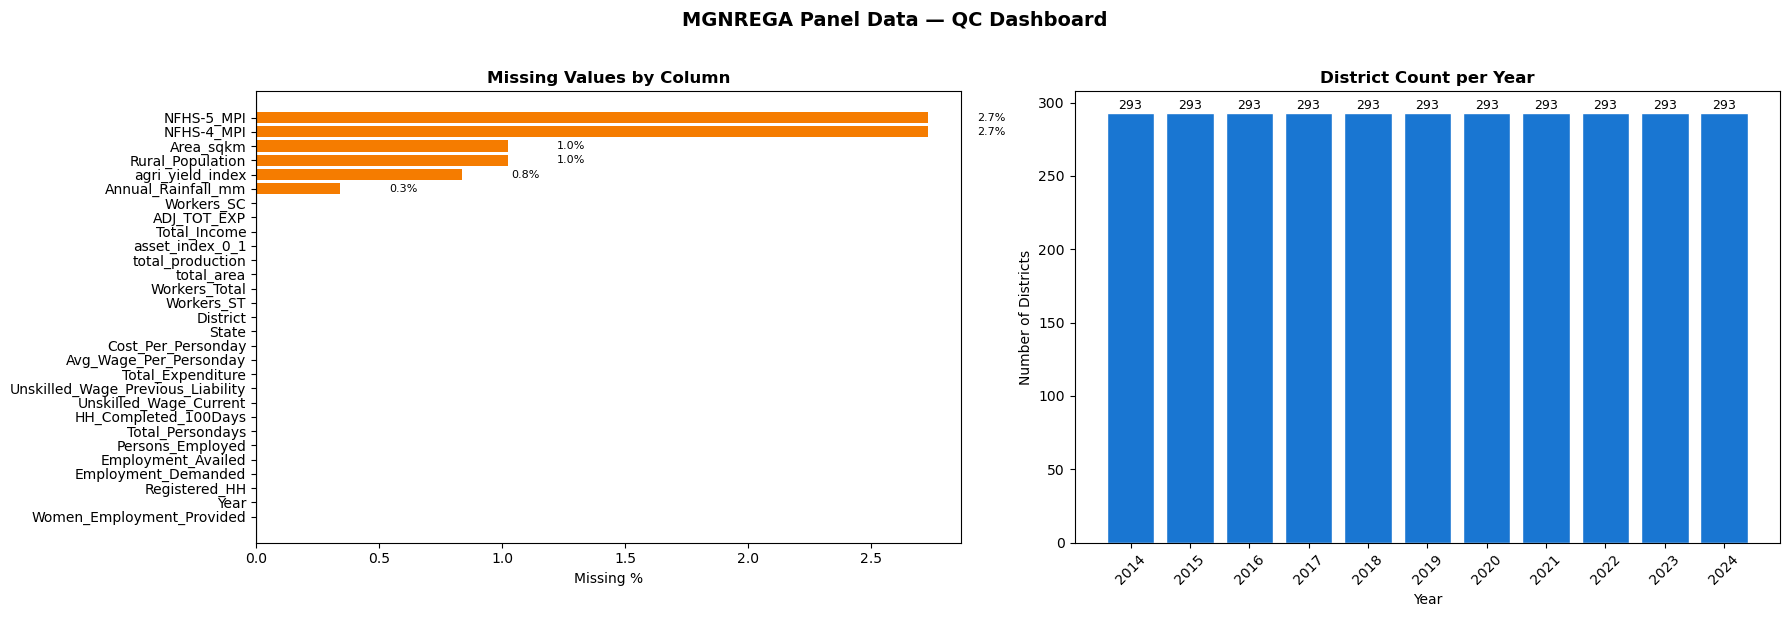

QC dashboard saved as panel_qc_dashboard.png


In [14]:
# ── 4. Missing value heatmap ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap: % missing per column
miss_pct = panel.isnull().mean() * 100
ax1 = axes[0]
miss_pct_sorted = miss_pct.sort_values(ascending=False)
colors = ['#d32f2f' if v > 10 else '#f57c00' if v > 0 else '#388e3c' for v in miss_pct_sorted]
ax1.barh(miss_pct_sorted.index, miss_pct_sorted.values, color=colors)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_xlabel('Missing %')
ax1.set_title('Missing Values by Column', fontweight='bold')
ax1.invert_yaxis()
for i, (col, val) in enumerate(zip(miss_pct_sorted.index, miss_pct_sorted.values)):
    if val > 0:
        ax1.text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=8)

# Bar: district count per year
ax2 = axes[1]
dist_per_year = panel.groupby('Year')['District'].nunique()
ax2.bar(dist_per_year.index.astype(int), dist_per_year.values, color='#1976d2', edgecolor='white')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Districts')
ax2.set_title('District Count per Year', fontweight='bold')
ax2.set_xticks(dist_per_year.index.astype(int))
ax2.set_xticklabels(dist_per_year.index.astype(int), rotation=45)
for x, y in zip(dist_per_year.index.astype(int), dist_per_year.values):
    ax2.text(x, y + 0.5, str(y), ha='center', va='bottom', fontsize=9)

plt.suptitle('MGNREGA Panel Data — QC Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('panel_qc_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('QC dashboard saved as panel_qc_dashboard.png')

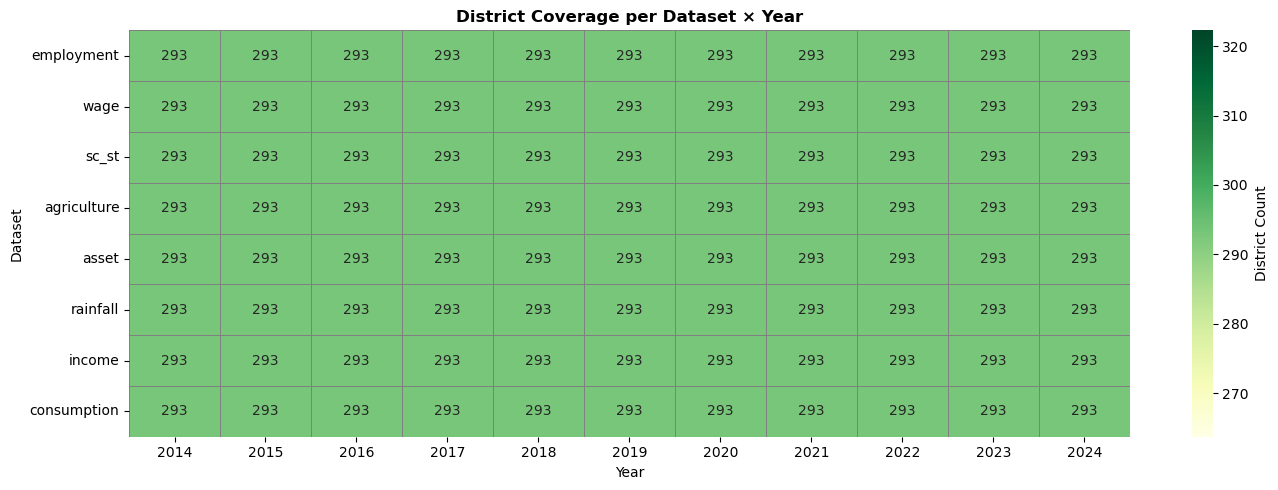

Coverage heatmap saved as panel_coverage_heatmap.png


In [15]:
# ── 5. Coverage heatmap per dataset × year ────────────────────────────────────
cov_data = {}
for key, df in panel_dfs.items():
    df_f = df[df['District'].isin(final_district_set) & df['Year'].isin(common_years)]
    cov_data[key] = df_f.groupby('Year')['District'].nunique()

cov_df = pd.DataFrame(cov_data).T
cov_df.columns = cov_df.columns.astype(int)

plt.figure(figsize=(14, 5))
sns.heatmap(cov_df, annot=True, fmt='d', cmap='YlGn',
            linewidths=0.5, linecolor='grey',
            cbar_kws={'label': 'District Count'})
plt.title('District Coverage per Dataset × Year', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Dataset')
plt.tight_layout()
plt.savefig('panel_coverage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Coverage heatmap saved as panel_coverage_heatmap.png')

## Cell 8 — Export

In [16]:
# ── Sort and export final panel ───────────────────────────────────────────────
panel = panel.sort_values(['District', 'Year']).reset_index(drop=True)

OUTPUT_FILE = 'final_panel_data.csv'
panel.to_csv(OUTPUT_FILE, index=False)
print(f'✔ Saved: {OUTPUT_FILE}')
print(f'   Shape: {panel.shape}')

# ── Update common_districts.csv with final district list ─────────────────────
pd.DataFrame({'District': sorted(final_districts)}).to_csv('common_districts.csv', index=False)
print(f'✔ Updated common_districts.csv with {len(final_districts)} districts')

# ── Print column list for reference ──────────────────────────────────────────
print('\nFinal panel columns:')
for i, col in enumerate(panel.columns, 1):
    print(f'  {i:3d}. {col}')

# ── Sample view ───────────────────────────────────────────────────────────────
panel.head(5)

✔ Saved: final_panel_data.csv
   Shape: (3223, 29)
✔ Updated common_districts.csv with 293 districts

Final panel columns:
    1. District
    2. State
    3. Year
    4. Registered_HH
    5. Employment_Demanded
    6. Employment_Availed
    7. Persons_Employed
    8. Total_Persondays
    9. HH_Completed_100Days
   10. Unskilled_Wage_Current
   11. Unskilled_Wage_Previous_Liability
   12. Total_Expenditure
   13. Avg_Wage_Per_Personday
   14. Cost_Per_Personday
   15. Women_Employment_Provided
   16. Workers_SC
   17. Workers_ST
   18. Workers_Total
   19. total_area
   20. total_production
   21. agri_yield_index
   22. asset_index_0_1
   23. Annual_Rainfall_mm
   24. Total_Income
   25. ADJ_TOT_EXP
   26. NFHS-4_MPI
   27. NFHS-5_MPI
   28. Rural_Population
   29. Area_sqkm


,District,State,Year,Registered_HH,Employment_Demanded,Employment_Availed,Persons_Employed,Total_Persondays,HH_Completed_100Days,Unskilled_Wage_Current,...,total_production,agri_yield_index,asset_index_0_1,Annual_Rainfall_mm,Total_Income,ADJ_TOT_EXP,NFHS-4_MPI,NFHS-5_MPI,Rural_Population,Area_sqkm
0,ADILABAD,TELANGANA,2014,644584,332146,280593,525708,14539265,30955,16403.40,...,728487.0,1.868965,0.248220,622.557999,10949.73709,66167110,0.125,0.064,1980980.0,15751.3
1,ADILABAD,TELANGANA,2015,669440,346659,299747,559369,16305987,33924,22881.45,...,1029344.0,2.383348,0.253957,588.611583,9899.68029,36999030,0.125,0.064,1980980.0,15751.3
2,ADILABAD,TELANGANA,2016,154851,90202,79765,152455,3652716,6553,5391.43,...,314102.0,2.471493,0.241636,696.647036,10431.21974,50151171,0.125,0.064,1980980.0,15751.3
3,ADILABAD,TELANGANA,2017,154142,94725,71569,136136,3510005,6667,5092.70,...,472749.0,2.866622,0.221671,459.747707,10710.20811,46861660,0.125,0.064,1980980.0,15751.3
4,ADILABAD,TELANGANA,2018,158980,80659,74113,139671,3613927,6637,5888.40,...,396773.0,2.377794,0.289445,850.179348,11432.91010,61421207,0.125,0.064,1980980.0,15751.3


In [21]:
panel.to_csv("Panel_Data 2014-24.csv", index= False )